# AI4I - Exploration

___

### Workflow

1. Load dataset
2. Preprocessing + : transforming, scaling, etc.
3. Feature engineering: build new features
4. Splitting data into train and test datasets
5. Build model
6. Evaluate
7. Improve model

### Measurement metrics

Since the dataset is highly imbalanced, we should focus on Recal, Precision, PR-AUC.

___

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

logger = logging.getLogger(__name__)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import lightgbm as lgb

from predictive_maintenance.data import load_train_data, split_train_test
from predictive_maintenance.preprocessing import drop_non_feature_columns
from predictive_maintenance.features import add_derived_features

from predictive_maintenance.evaluate import evaluate_model, find_threshold_for_recall
from predictive_maintenance.visualization import (
    plot_precision_recall_curve,
    plot_precision_recall_vs_threshold,
)
from predictive_maintenance.explainability import explain_predictions
from predictive_maintenance.visualization import plot_shap_bar, plot_shap_beeswarm

### Loade dataset

In [5]:
data = load_train_data(file_path="../data/ai4i2020.csv")

display(data.head())

2026-07-23 17:20:30 | INFO     | predictive_maintenance.data | Data loaded successfully from ../data/ai4i2020.csv


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Preprocessing

- Since UDI (or UID) is not usable for this problem, we can simply remove it.
- For the v1, we keep only `Machine failure` target instead of the five target features.
- Enconde Type (i.e. use One-Hot-Enconde).
- Features `TWF/HDF/PWF/OSF/RNF` are excluded because they are sub-components of
the failure label itself (empirically, ~99.7% consistent with
Machine failure = OR of these five flags), so including them as
inputs would leak the answer into the feature set.

In [6]:
pp_data = drop_non_feature_columns(df=data)

display(pp_data.head())

2026-07-23 17:20:34 | INFO     | predictive_maintenance.preprocessing | Dropping 7 non-feature columns: ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


### Feature engineering

Engineer the following features:

- **temp_diff**: process temperature minus air temperature, isolating
    the heat generated by the cutting process itself (friction) from
    ambient conditions. A large temp_diff is the signal most directly
    associated with heat dissipation failure (HDF).

- **power**: torque x rotational speed (converted to rad/s), approximating
    mechanical power. This recreates, from first principles, the
    physical quantity most associated with power failure (PWF).


In [7]:
pp_data = add_derived_features(df=pp_data)

display(pp_data.head())

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temp_diff,power
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.584688
1,L,298.2,308.7,1408,46.3,3,0,10.5,6826.716958
2,L,298.1,308.5,1498,49.4,5,0,10.4,7749.380997
3,L,298.2,308.6,1433,39.5,7,0,10.4,5927.499652
4,L,298.2,308.7,1408,40.0,9,0,10.5,5897.811627


### Modeling

In [8]:
TARGET = "Machine failure"
RSTATE = 42
TEST_SIZE = 0.2

CATEGORICAL_FEATURES = ["Type"]
NUMERIC_FEATURES = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
    "temp_diff", "power"
]

In [9]:
X_train, X_test, y_train, y_test = split_train_test(
    df = pp_data,
    target_col = TARGET,
    test_size = TEST_SIZE,
    random_state = RSTATE
)

2026-07-23 17:20:41 | INFO     | predictive_maintenance.data | Splitting data: test_size=0.2, stratify=True
2026-07-23 17:20:41 | INFO     | predictive_maintenance.data | Train shape: (8000, 8), Test shape: (2000, 8)


In [10]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", "passthrough", NUMERIC_FEATURES),
])

model = lgb.LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=RSTATE
)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", model),
])

pipeline.fit(X_train, y_train)

y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000787 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1266
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


**Note**
- Usei passthrough para as features numéricas porque LightGBM, sendo baseado em árvores, é invariante à escala das features, escalar não mudaria as decisões de corte do modelo, então adicionar um StandardScaler seria complexidade desnecessária no pipeline."

#### Evaluation

- Accuracy is deliberately excluded: a model predicting "no failure"
    for every row would score ~96.6% accuracy while being operationally
    useless. PR-AUC is used as the primary metric because it summarizes
    performance across all thresholds without being inflated by the
    large number of true negatives, unlike ROC-AUC.

- Find the lowest decision threshold that achieves at least the target
    recall. Given the operational cost asymmetry (a missed failure costs
    far more than a false alarm), the threshold is chosen to favor recall
    rather than defaulting to the standard 0.5 cutoff.

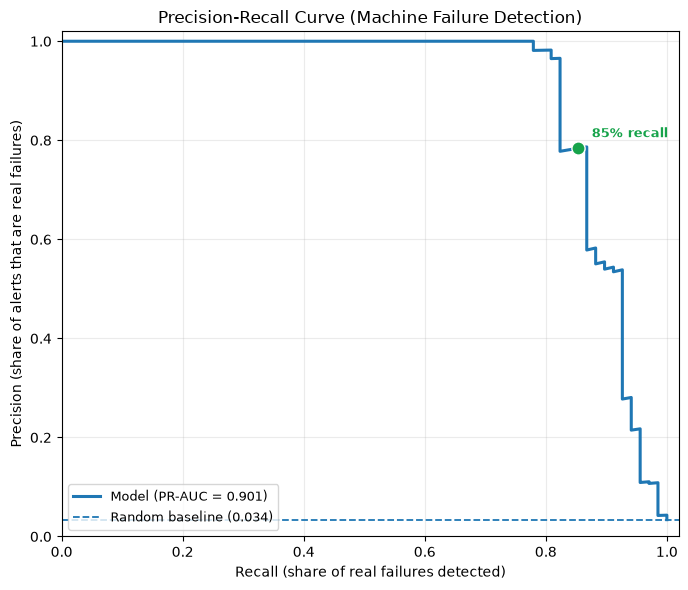

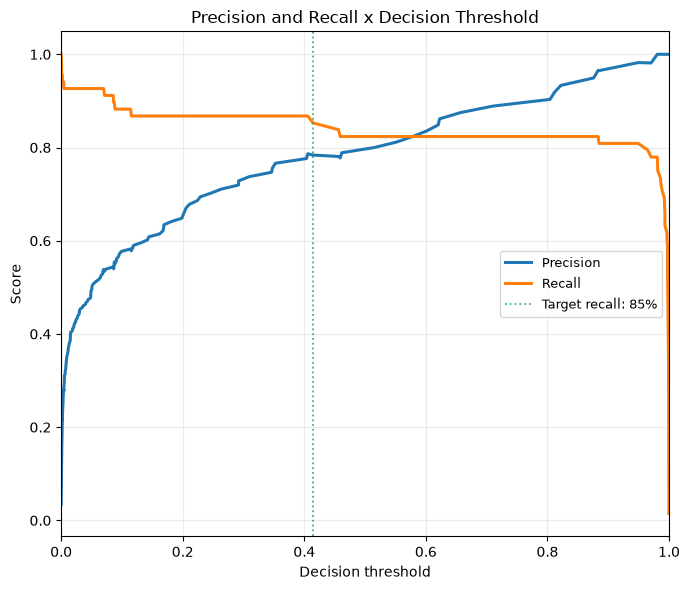

/Users/soutogustavo/Labs84/AI4I_predictive_maintenance/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


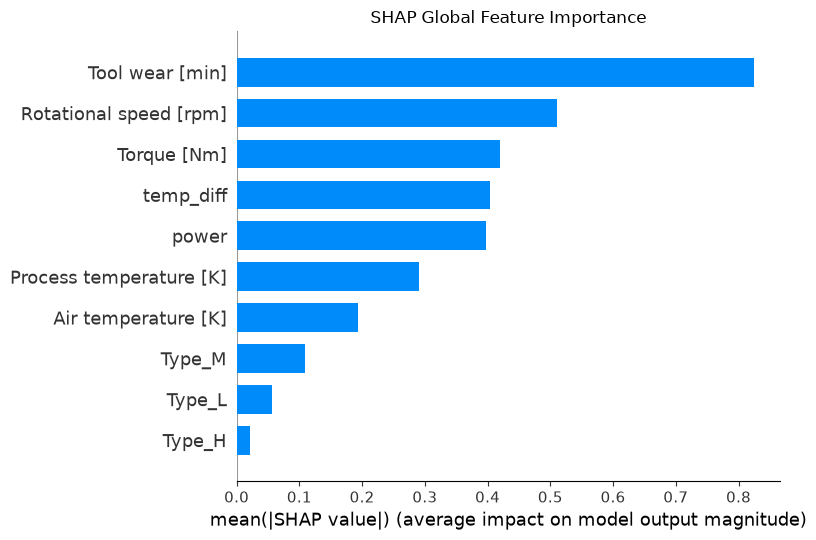

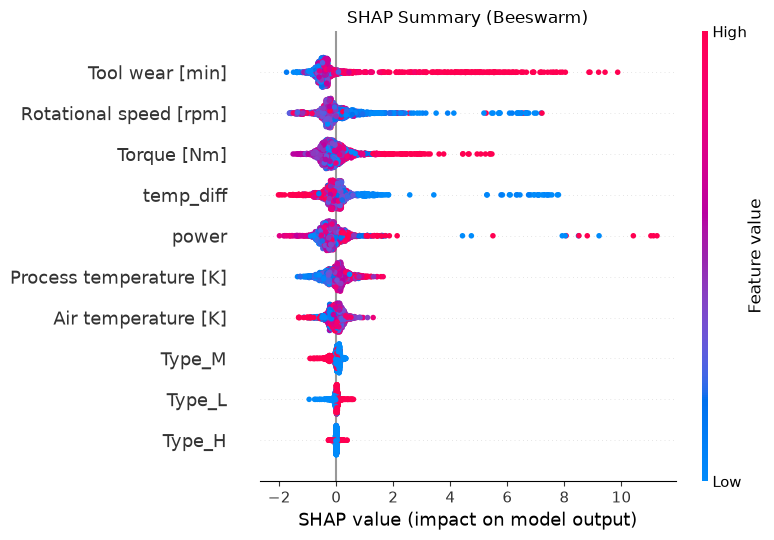

In [21]:
TARGET_RECALL = 0.85 # .90

threshold = find_threshold_for_recall(y_test, y_pred_proba, target_recall=TARGET_RECALL)
metrics = evaluate_model(y_test, y_pred_proba, threshold=threshold)

plot_precision_recall_curve(y_test, y_pred_proba, plot_fig=True, save_fig=False)
plot_precision_recall_vs_threshold(y_test, y_pred_proba, plot_fig=True, save_fig=False)

shap_values, feature_names = explain_predictions(pipeline, X_test)
clean_names = [n.replace("num__", "").replace("cat__", "") for n in feature_names]
X_test_transformed = pipeline.named_steps["preprocessing"].transform(X_test)

plot_shap_bar(shap_values, X_test_transformed, clean_names, plot_fig=True, save_fig=False)
plot_shap_beeswarm(shap_values, X_test_transformed, clean_names, plot_fig=True, save_fig=False)

___